# Rescaled beta QC

The goal of the analysis is to check the distribution of the rescaled beta


## Data loading

The data required for the analysis is loaded from the `computed maf` dataset.


In [ ]:
import narwhals as nw
import numpy as np
import patchworklib
import plotnine as p9
from gentropy.common.session import Session
from pandas.api.types import CategoricalDtype
from pyspark.sql import functions as f

from manuscript_methods import OpenTargetsTheme, group_statistics
from manuscript_methods.datasets import LeadVariantEffect


In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})
lead_maf_dataset_path = "../../data/intermediate_files/lead_variant_effect"


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 14:48:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
session.spark


In [4]:
dataset_maf = LeadVariantEffect.from_parquet(session, lead_maf_dataset_path)
REM = 10


## Direction of effect counts

The direction of effect is stored under the `rescaledStatistics.directionOfEffect`

  directionOfEffect    count        label     %
0           Unknown    52385     N=52,385   1.8
1          Negative  1320434  N=1,320,434  46.6
2          Positive  1460939  N=1,460,939  51.6


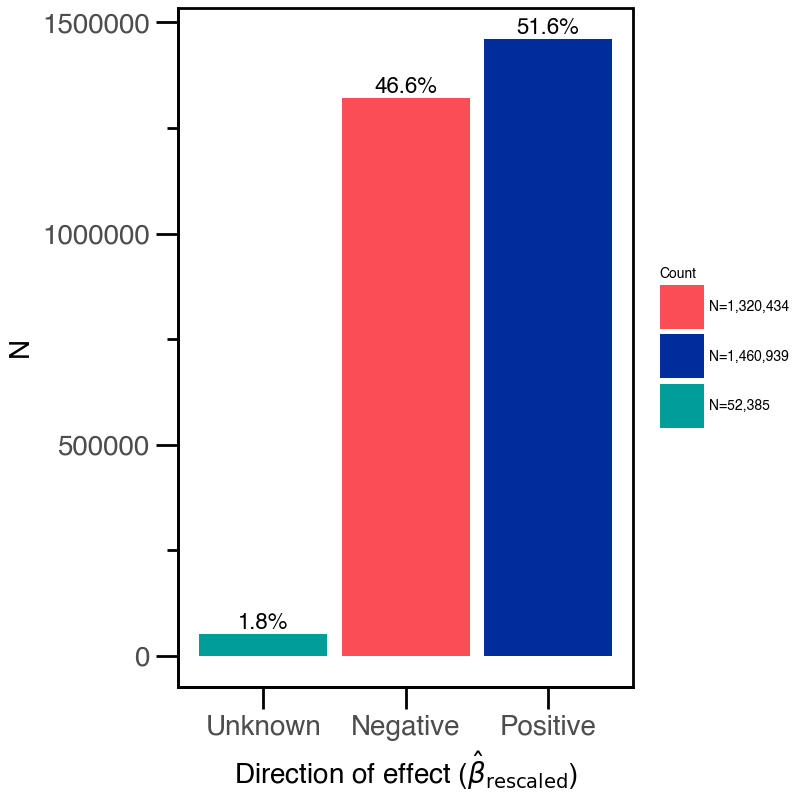

In [55]:
direction_of_effect = (
    dataset_maf.df.select("rescaledStatistics.directionOfEffect").groupby("directionOfEffect").count().toPandas()
)

direction_of_effect["label"] = "N=" + direction_of_effect["count"].apply(lambda x: f"{x:,}")
total = direction_of_effect["count"].sum()
direction_of_effect["%"] = round((direction_of_effect["count"] / total) * 100, 1)
direction_of_effect["directionOfEffect"] = (
    direction_of_effect["directionOfEffect"].map({1: "Positive", -1: "Negative", np.nan: "Unknown"}).astype("category")
)
direction_of_effect = direction_of_effect.sort_values(by="count").reset_index(drop=True)
print(direction_of_effect)
p1 = (
    p9.ggplot(
        data=direction_of_effect,
        mapping=p9.aes(
            x="reorder(directionOfEffect, count)",
            y="count",
            fill="label",
        ),
    )
    + p9.geom_col(stat="identity")
    + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors)
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.geom_text(
        p9.aes(label="%"),
        size=8,
        va="bottom",
        format_string="{}%",
    )
    + p9.labs(
        x=r"Direction of effect ($\hat{\beta}_{\mathrm{rescaled}}$)",
        y="N",
        fill="Count",
    )
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
    )
    + p9.theme(legend_position="right", figure_size=(4, 4))
)

p1.save("plots/01.2_direction_of_effect.jpg", dpi=300, bbox_inches="tight")
p1


## Rescaled beta nullability counts

The analysis inspects the nullability of the rescaled beta estimates.

  absEstimatedBetaIsNull    count        label     %
0                    yes    13290     N=13,290   0.5
1                     no  2820468  N=2,820,468  99.5
  estimatedBetaIsNull    count        label     %
0                 yes    64230     N=64,230   2.3
1                  no  2769528  N=2,769,528  97.7


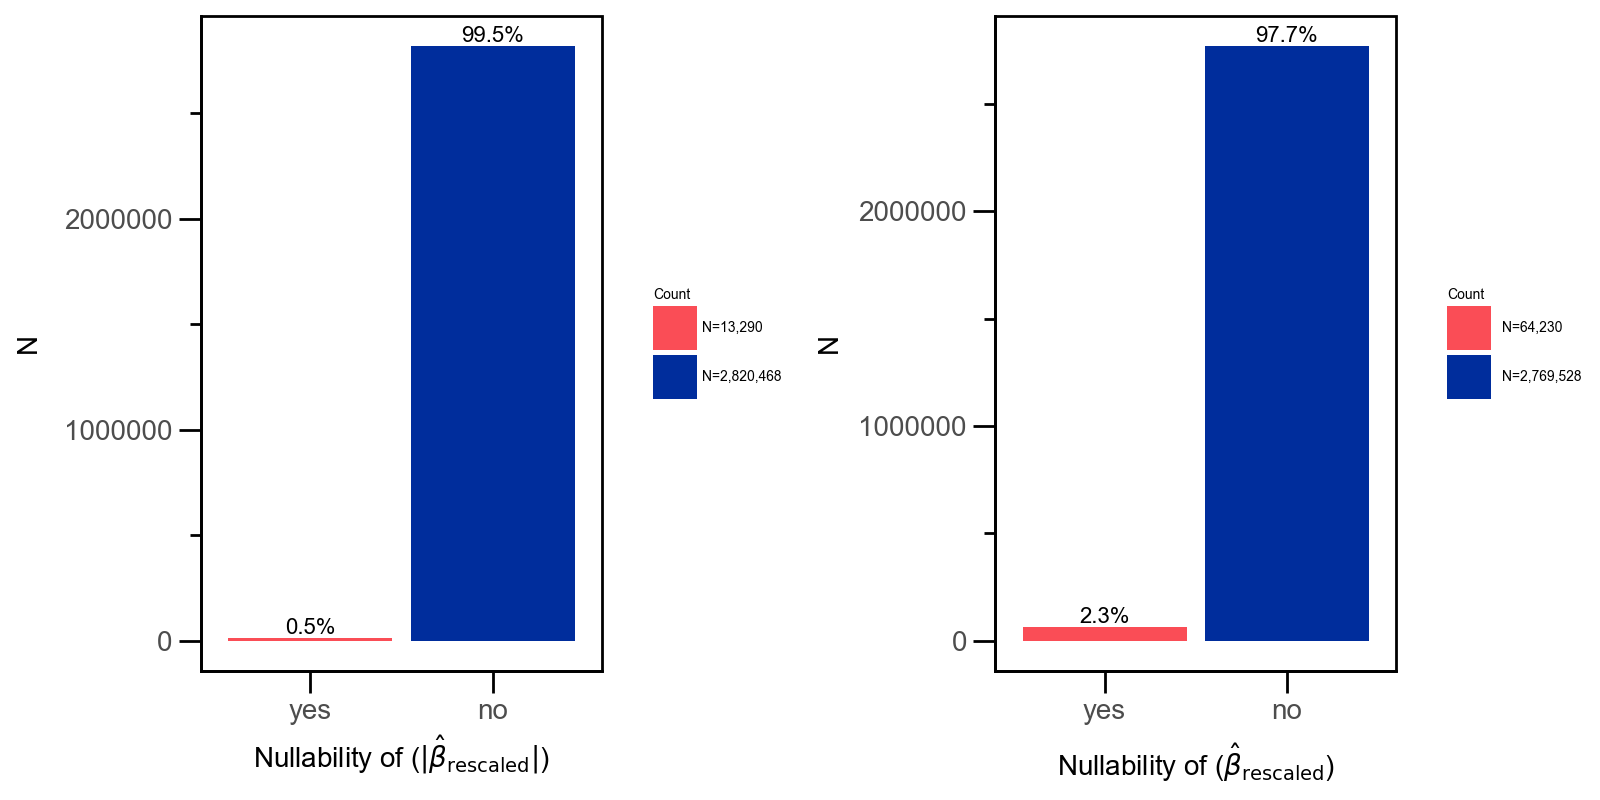

In [ ]:
order = ["yes", "no"]
cat_type = CategoricalDtype(categories=order, ordered=True)
rescaled_abs_effect = (
    dataset_maf.df.select(
        f.col("rescaledStatistics.absEstimatedBeta").alias("absEstimatedBeta"),
    )
    .withColumn("absEstimatedBetaIsNull", f.when(f.col("absEstimatedBeta").isNull(), True).otherwise(False))
    .groupBy("absEstimatedBetaIsNull")
    .count()
    .toPandas()
)


rescaled_abs_effect["label"] = "N=" + rescaled_abs_effect["count"].apply(lambda x: f"{x:,}")
total = rescaled_abs_effect["count"].sum()
rescaled_abs_effect["%"] = round((rescaled_abs_effect["count"] / total) * 100, 1)
rescaled_abs_effect["absEstimatedBetaIsNull"] = (
    rescaled_abs_effect["absEstimatedBetaIsNull"].apply(lambda x: "yes" if x else "no").astype(cat_type)
)
names = dict(zip(rescaled_abs_effect.absEstimatedBetaIsNull, rescaled_abs_effect.label))

rescaled_abs_effect = rescaled_abs_effect.sort_values(by="count").reset_index(drop=True)
print(rescaled_abs_effect)
plot = (
    p9.ggplot(
        data=rescaled_abs_effect,
        mapping=p9.aes(
            x="reorder(absEstimatedBetaIsNull, count)",
            y="count",
            fill="absEstimatedBetaIsNull",
        ),
    )
    + p9.geom_col(stat="identity")
    + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors, labels=names)
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.geom_text(
        p9.aes(label="%"),
        size=8,
        va="bottom",
        format_string="{}%",
    )
    + p9.labs(
        x=r"Nullability of ($|\hat{\beta}_{\mathrm{rescaled}}|$)",
        y="N",
        fill="Count",
    )
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
    )
    + p9.theme(legend_position="right", figure_size=(4, 4))
)


rescaled_effect = (
    dataset_maf.df.select(
        (f.col("rescaledStatistics.absEstimatedBeta") * f.col("rescaledStatistics.directionOfEffect")).alias(
            "estimatedBeta"
        ),
    )
    .withColumn("estimatedBetaIsNull", f.when(f.col("estimatedBeta").isNull(), True).otherwise(False))
    .groupBy("estimatedBetaIsNull")
    .count()
    .toPandas()
)


rescaled_effect["label"] = "N=" + rescaled_effect["count"].apply(lambda x: f"{x:,}")
total = rescaled_effect["count"].sum()
rescaled_effect["%"] = round((rescaled_effect["count"] / total) * 100, 1)
rescaled_effect["estimatedBetaIsNull"] = (
    rescaled_effect["estimatedBetaIsNull"].apply(lambda x: "yes" if x else "no").astype(cat_type)
)
rescaled_effect = rescaled_effect.sort_values(by="count").reset_index(drop=True)
names = dict(zip(rescaled_effect.estimatedBetaIsNull, rescaled_effect.label))
print(rescaled_effect)
plot2 = (
    p9.ggplot(
        data=rescaled_effect,
        mapping=p9.aes(
            x="reorder(estimatedBetaIsNull, count)",
            y="count",
            fill="estimatedBetaIsNull",
        ),
    )
    + p9.geom_col(stat="identity")
    + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors[0:2], labels=names)
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.geom_text(
        p9.aes(label="%"),
        size=8,
        va="bottom",
        format_string="{}%",
    )
    + p9.labs(
        x=r"Nullability of ($\hat{\beta}_{\mathrm{rescaled}}$)",
        y="N",
        fill="Count",
    )
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
    )
    + p9.theme(legend_position="right", figure_size=(8, 4))
)
p2 = plot | plot2

p2.save("plots/01.2_rescaled_effect_null_counts.jpg", dpi=300, bbox_inches="tight")

p2


## Plot the distribution of estimated beta

The distribution of the rescaled beta is plotted using a histogram. The x-axis represents the rescaled beta values, while the y-axis shows the frequency of these values.

The y-axis is limited to the 1000, to see the distribution tails more clearly.


In [29]:
est_beta = dataset_maf.df.select(
    "rescaledStatistics.absEstimatedBeta",
    "rescaledStatistics.minorAlleleEstimatedBeta",
    "originalBeta",
    (f.col("rescaledStatistics.absEstimatedBeta") * f.col("rescaledStatistics.directionOfEffect")).alias(
        "estimatedBeta"
    ),
).toPandas()
est_beta.describe()


,absEstimatedBeta,minorAlleleEstimatedBeta,originalBeta,estimatedBeta
count,2.820468e+06,2.769528e+06,2.781497e+06,2.769528e+06
mean,1.086584e+00,2.782455e-01,5.148029e-01,2.316678e-01
std,3.286030e+00,3.370928e+00,1.001394e+02,3.374449e+00
min,4.543499e-03,-5.761040e+02,-1.575079e+04,-5.761040e+02
25%,2.913274e-01,-5.697374e-01,-4.791470e-01,-6.088255e-01
50%,6.522378e-01,2.601966e-02,1.008035e-02,1.833709e-02
75%,1.035307e+00,7.515759e-01,5.655500e-01,7.170052e-01
max,8.201783e+02,2.933175e+02,7.872900e+04,2.933175e+02


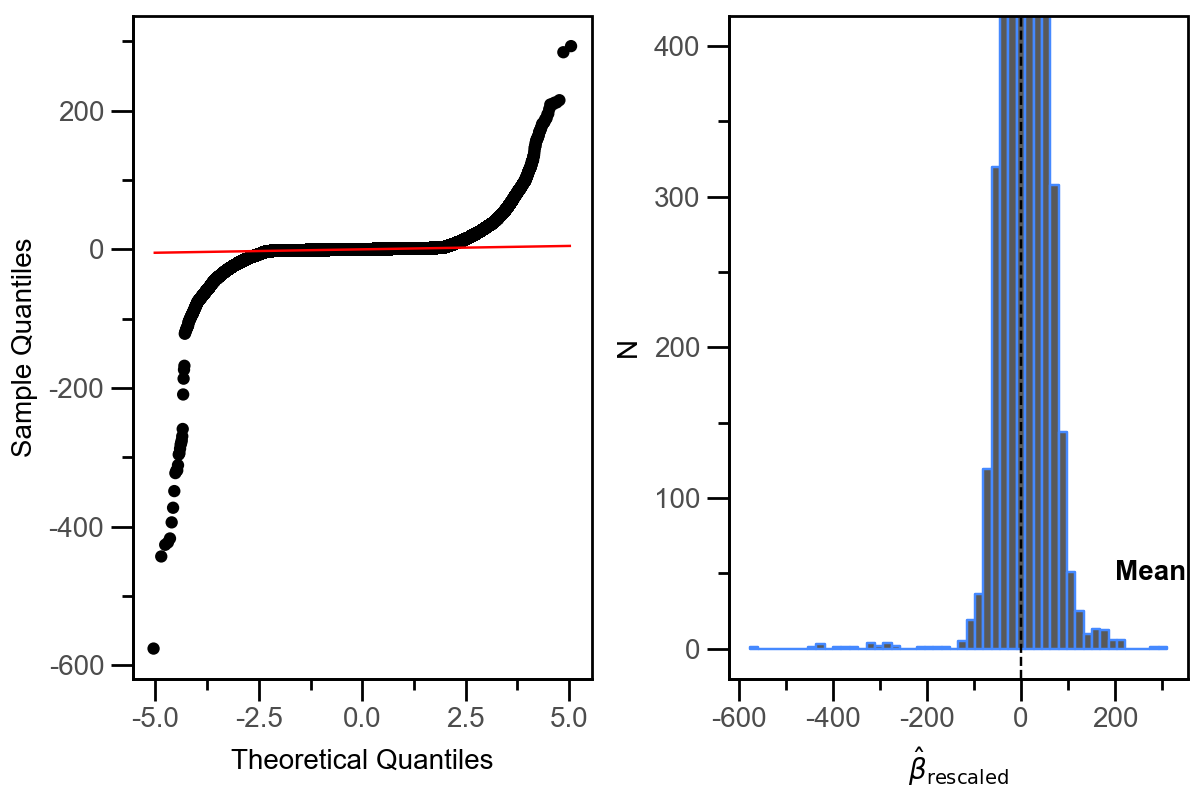

In [57]:
REM = 10
mean_val = est_beta["estimatedBeta"].mean()
median_val = est_beta["estimatedBeta"].median()
xmax = est_beta["estimatedBeta"].max()
xmin = est_beta["estimatedBeta"].min()
ymax = 100

p = (
    p9.ggplot(data=est_beta, mapping=p9.aes(x="estimatedBeta"))
    + p9.geom_histogram(
        bins=50,
        color=OpenTargetsTheme.categorical_light_colors[1],
    )
    + p9.coord_cartesian(ylim=(0, 400))  # limit y-axis to hide the spike
    + p9.labs(x=r"$\hat{\beta}_{\mathrm{rescaled}}$", y="N")
    + p9.geom_vline(xintercept=mean_val, color="black", linetype="dashed", size=0.5, show_legend=True)
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.annotate(
        "text",
        x=mean_val + 200,
        y=50,
        label=f"Mean = {mean_val:.2f}",
        ha="left",
        size=REM,
        color="black",
        fontweight="bold",
    )
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
        figure_size=(6, 4),
    )
)


qq_plot = (
    p9.ggplot(data=est_beta, mapping=p9.aes(sample="estimatedBeta"))
    + p9.stat_qq()
    + p9.stat_qq_line(color="red")
    + p9.labs(x="Theoretical Quantiles", y="Sample Quantiles")
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.theme(
        figure_size=(8, 4),
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
    )
)

p3 = qq_plot | p


p3.save("plots/01.2_rescaled_betas.jpg", dpi=300, bbox_inches="tight")
p3


## Plot the minor allele estimated beta

minor allele estimated beta (similar for estimated beta, but swapped the sign of the beta when the effect allele is major)

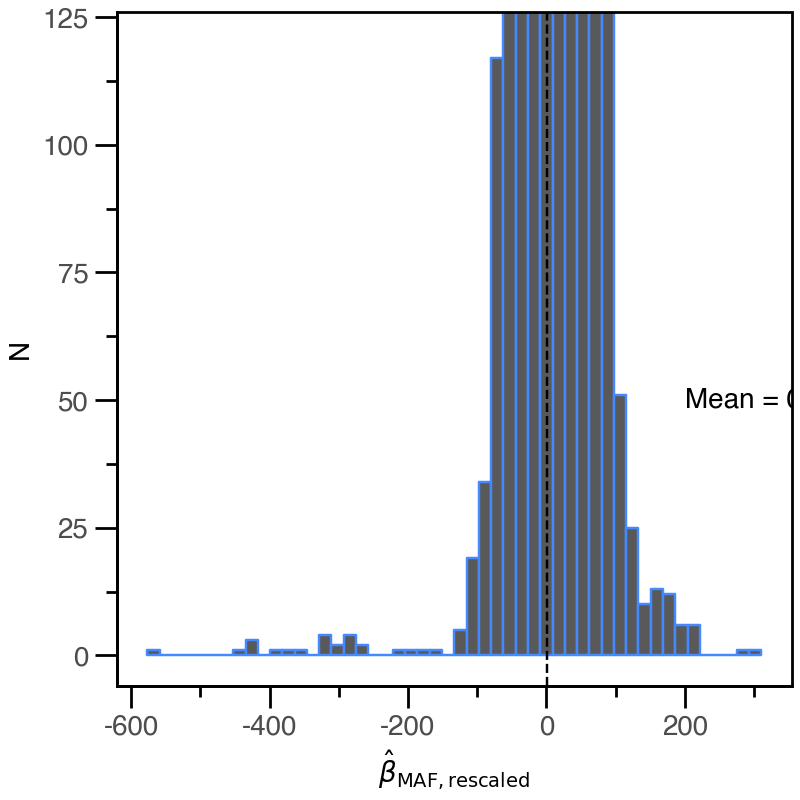

In [59]:
REM = 10
mean_val = est_beta["minorAlleleEstimatedBeta"].mean()
median_val = est_beta["minorAlleleEstimatedBeta"].median()
xmax = est_beta["minorAlleleEstimatedBeta"].max()
xmin = est_beta["minorAlleleEstimatedBeta"].min()
ymax = 100


p4 = (
    p9.ggplot(data=est_beta, mapping=p9.aes(x="minorAlleleEstimatedBeta"))
    + p9.geom_histogram(
        bins=50,
        color=OpenTargetsTheme.categorical_light_colors[1],
    )
    + p9.coord_cartesian(ylim=(0, 120))  # limit y-axis to hide the spike
    + p9.labs(x=r"$\hat{\beta}_{\mathrm{MAF,rescaled}}$", y="N")
    + p9.geom_vline(xintercept=mean_val, color="black", linetype="dashed", size=0.5, show_legend=True)
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.annotate(
        "text",
        x=mean_val + 200,
        y=50,
        label=f"Mean = {mean_val:.2f}",
        ha="left",
        size=REM,
        color="black",
        fontweight="bold",
    )
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
        figure_size=(4, 4),
    )
)


p4.save("plots/01.2_minor_allele_rescaled_betas.jpg", dpi=300, bbox_inches="tight")
p4


## Find the cutoff on the rescaled beta size


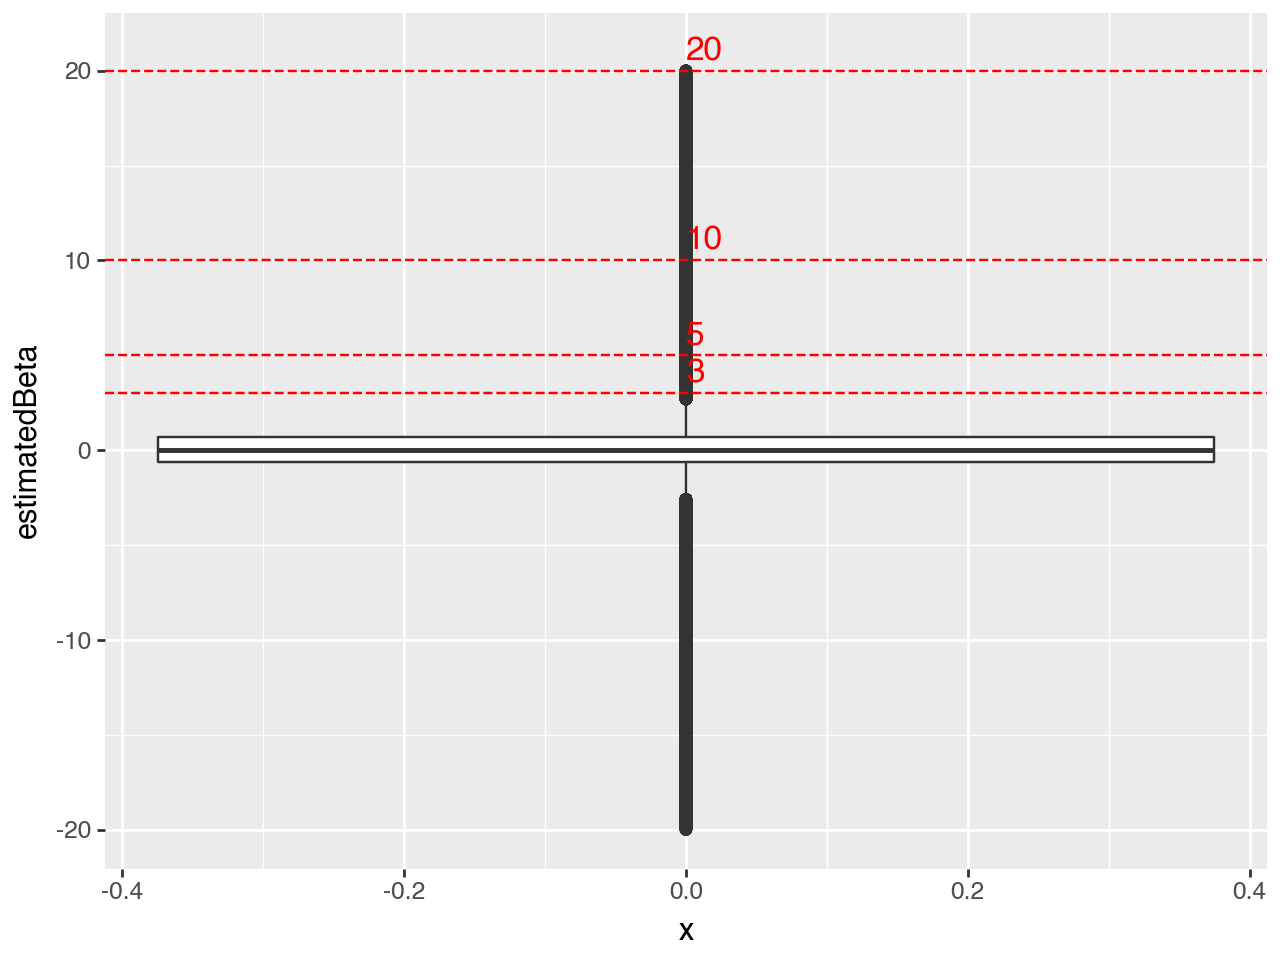

In [60]:
plot = (
    p9.ggplot(data=est_beta[abs(est_beta["estimatedBeta"]) < 20], mapping=p9.aes(y="estimatedBeta")) + p9.geom_boxplot()
)

for v in [3, 5, 10, 20]:
    plot += p9.geom_hline(yintercept=v, color="red", linetype="dashed", size=0.5, show_legend=True)
    plot += p9.annotate(
        "text",
        x=0,
        y=v + 1,
        label=f"{v}",
        ha="left",
        size=12,
        color="red",
        fontweight="bold",
    )
plot


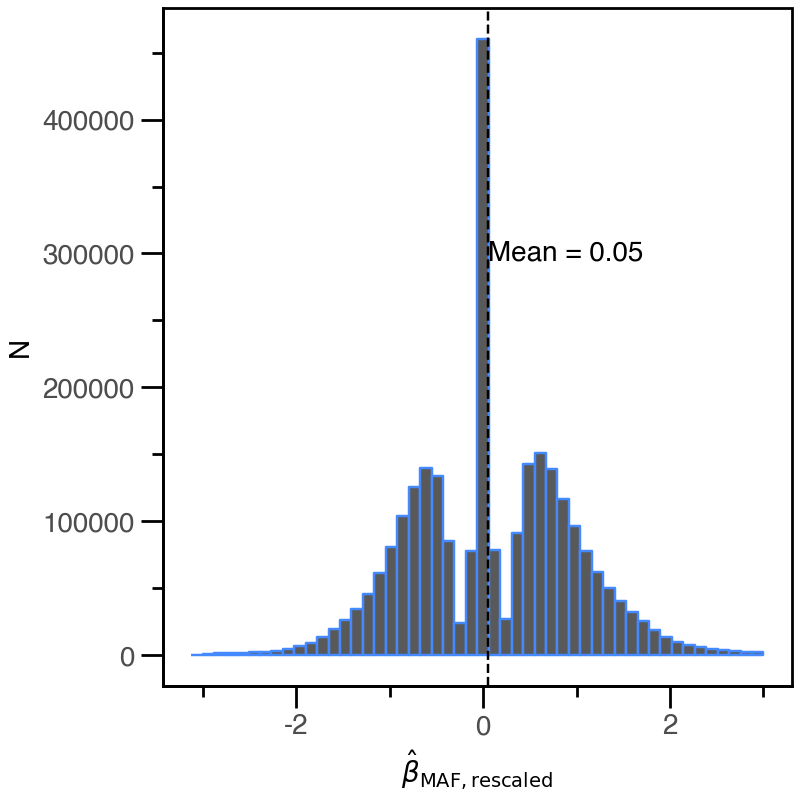

In [61]:
REM = 10
data = est_beta[abs(est_beta["estimatedBeta"]) < 3]
mean_val = data["estimatedBeta"].mean()
median_val = data["estimatedBeta"].median()
xmax = data["estimatedBeta"].max()
xmin = data["estimatedBeta"].min()
ymax = 100


p5 = (
    p9.ggplot(data=data, mapping=p9.aes(x="minorAlleleEstimatedBeta"))
    + p9.geom_histogram(
        bins=50,
        color=OpenTargetsTheme.categorical_light_colors[1],
    )
    + p9.labs(x=r"$\hat{\beta}_{\mathrm{MAF,rescaled}}$", y="N")
    + p9.geom_vline(xintercept=mean_val, color="black", linetype="dashed", size=0.5, show_legend=True)
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.annotate(
        "text",
        x=mean_val,
        y=ymax * 3000,
        label=f"Mean = {mean_val:.2f}",
        ha="left",
        size=REM,
        color="black",
        fontweight="bold",
    )
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
        figure_size=(4, 4),
    )
)


p5.save("plots/01.2_rescaled_betas_after_filter.jpg", dpi=300, bbox_inches="tight")
p5


## Compare the two estimated betas

- calculate the correlation
- calculate the % of difference between the two betas


In [43]:
corr = est_beta[["estimatedBeta", "minorAlleleEstimatedBeta"]].corr()
corr


,estimatedBeta,minorAlleleEstimatedBeta
estimatedBeta,1.000000,0.937993
minorAlleleEstimatedBeta,0.937993,1.000000


In [62]:
group_stats = group_statistics(
    dataset_maf.df.select(
        (f.col("rescaledStatistics.absEstimatedBeta") * f.col("rescaledStatistics.directionOfEffect")).alias(
            "estimatedBeta"
        ),
        "rescaledStatistics.minorAlleleEstimatedBeta",
    ).withColumn(
        "betaMatch",
        f.when(f.col("estimatedBeta") == f.col("minorAlleleEstimatedBeta"), f.lit(True)).otherwise(False),
    ),
    f.col("betaMatch"),
).orderBy(f.desc("count"))

group_stats.show()


+---------+-------+-----+----------------+
|betaMatch|  count|    %|      percentage|
+---------+-------+-----+----------------+
|     true|2057063|72.59|72.5913433680646|
|    false| 776695|27.41|27.4086566319354|
+---------+-------+-----+----------------+



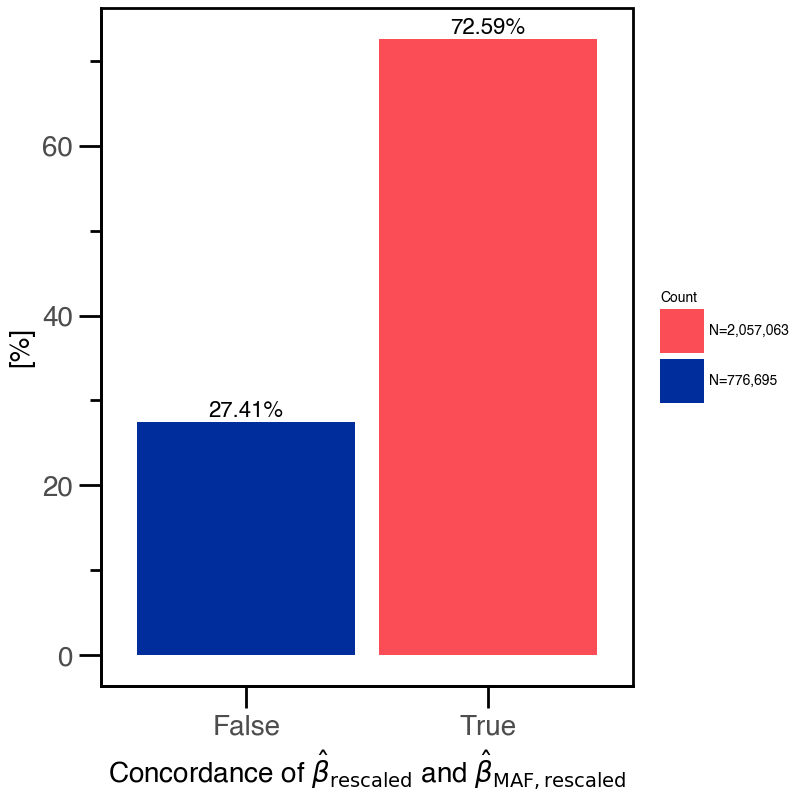

In [63]:
data = group_stats.toPandas()
data["label"] = "N=" + data["count"].apply(lambda x: f"{x:,}")
p6 = (
    p9.ggplot(data=data, mapping=p9.aes(x="betaMatch", y="percentage", fill="label"))
    + p9.geom_col(stat="identity")
    + p9.scale_fill_manual(values=OpenTargetsTheme.categorical_dark_colors)
    + OpenTargetsTheme.categorical_theme(REM=5)
    + p9.geom_text(
        p9.aes(label="%"),
        size=8,
        va="bottom",
        format_string="{}%",
    )
    + p9.labs(
        x=r"Concordance of $\hat{\beta}_{\mathrm{rescaled}}$ and $\hat{\beta}_{\mathrm{MAF,rescaled}}$",
        y="[%]",
        fill="Count",
    )
    + p9.theme(
        axis_text_x=p9.element_text(size=REM, family="sans-serif", va="top", ha="center", rotation=0),
        axis_title_x=p9.element_text(size=REM, family="sans-serif"),
        figure_size=(4, 4),
        legend_position="right",
    )
)

p6.save("plots/01.2_betas_concordance.jpg", dpi=300, bbox_inches="tight")
p6


## Compare the estimated effect size and original effect size


In [ ]:
corr = est_beta[["estimatedBeta", "originalBeta"]].corr()
corr


,estimatedBeta,originalBeta
estimatedBeta,1.00000,0.01916
originalBeta,0.01916,1.00000
